# Method 3: ESM2 Foundation Model Embeddings for Protein Function Retrieval

**Project:** Benchmarking Protein Function Retrieval — BLAST vs k-mer vs ESM2  
**Course:** COMPSCI 690U — Final Project  
**Team:** Sameeksha Bhatia · Shreya Arathi · Sivaraaman Balakrishnan · Sergey Semibratov

---

## Overview

This notebook implements **Method 3**: dense retrieval using [ESM2](https://huggingface.co/facebook/esm2_t33_650M_UR50D) protein language model embeddings.
We evaluate three model scales (35M, 150M, 650M parameters) on two DGEB retrieval tasks:

| Task | Queries | Corpus |
|------|---------|--------|
| **Arch Retrieval** | 2,343 archaeal proteins | 9,229 bacterial proteins |
| **Euk Retrieval** | 311 eukaryotic proteins | 3,202 bacterial proteins |

**Primary metric:** MAP@5  
**Secondary metrics:** nDCG@5, Recall@5  
**Reference upper bound:** ESM2-3B MAP@5 = 0.313 (Arch), 0.357 (Euk) — from DGEB paper

### Bug fixes applied vs original notebook
1. **Sentinel token masking** — `<cls>` and `<eos>` tokens are now correctly excluded from mean-pooling
2. **bfloat16 mixed precision** — ESM2-650M is loaded in bfloat16 to halve VRAM usage (critical for T4/A100)
3. **Zero BLAST hits** — queries with no BLAST hit are correctly assigned pident=0.0 (twilight zone)
4. **qrels format** — relevant set uses `set(qrels[qid].keys())` consistently throughout

### Notebook Sections
1. Environment setup & GPU verification  
2. Install & import dependencies  
3. Load DGEB datasets (Arch + Euk)  
4. ESM2 embedding extraction (middle + last encoder layers) — **FIXED**  
5. Cosine similarity retrieval (top-5)  
6. Evaluation: MAP@5, nDCG@5, Recall@5  
7. Twilight zone analysis  
8. Visualization & results table  

---
## Section 1: Environment Setup & GPU Check

In [2]:
import subprocess, sys, os

gpu_info = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv,noheader'],
    capture_output=True, text=True
)
if gpu_info.returncode == 0:
    print('GPU detected:', gpu_info.stdout.strip())
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU.')
    print('ESM2-650M needs ~6 GB VRAM in bfloat16 — T4 (16 GB) is sufficient.')

import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device     : {torch.cuda.get_device_name(0)}')
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM            : {total_gb:.1f} GB')
    if total_gb < 12:
        print('WARNING: < 12 GB VRAM detected. ESM2-650M may OOM even in bfloat16.')
        print('Consider using only 35M and 150M models.')

GPU detected: NVIDIA A100-SXM4-40GB, 40960 MiB, 40442 MiB
PyTorch version : 2.10.0+cu128
CUDA available  : True
CUDA device     : NVIDIA A100-SXM4-40GB
VRAM            : 42.4 GB


---
## Section 2: Install & Import Dependencies

In [3]:
%pip install -q dgeb transformers accelerate datasets scikit-learn pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 24.9 MB/s eta 0:00:00


In [4]:
import os
import json
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Checkpoint directory — override below if using Google Drive
CHECKPOINT_DIR = '/content/esm2_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoint directory: {CHECKPOINT_DIR}')

Using device: cuda
Checkpoint directory: /content/esm2_checkpoints


In [ ]:
# Mount Google Drive to persist checkpoints across session reconnects.
# Strongly recommended: ESM2-650M on Arch corpus takes ~20 min to embed.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKPOINT_DIR = '/content/drive/MyDrive/esm2_checkpoints_690U'
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print(f'Drive mounted. Checkpoints will be saved to: {CHECKPOINT_DIR}')
except ImportError:
    print('Not running in Colab — checkpoints saved locally to', CHECKPOINT_DIR)

---
## Section 3: Load DGEB Datasets

Datasets are loaded via the `dgeb` package task classes which reference pinned HuggingFace revision hashes.

| Task | Sequences dataset | Qrels dataset |
|---|---|---|
| **Arch Retrieval** | `tattabio/arch_retrieval` | `tattabio/arch_retrieval_qrels` |
| **Euk Retrieval** | `tattabio/euk_retrieval` | `tattabio/euk_retrieval_qrels` |

**Verified dataset structure:**
- `train` split = bacterial corpus (`Entry`, `Sequence`)
- `test` split = archaeal/eukaryotic queries (`Entry`, `Sequence`)
- qrels: only relevant pairs stored (`fuzz_ratio = 1.0` for all stored pairs)
- All stored pairs are relevant by definition — non-relevant pairs are absent entirely

In [ ]:
from dgeb.tasks import ArchRetrieval, EukRetrieval
from collections import defaultdict


def load_dgeb_task(task_class, task_name):
    """
    Load queries, corpus and qrels for a DGEB retrieval task.

    Verified dataset structure (dgeb v0.2.0):
    - datasets[0]: sequences — train=corpus, test=queries
    - datasets[1]: qrels — only relevant pairs stored (fuzz_ratio=1.0 for all)
      Non-relevant pairs are absent entirely from this dataset.

    Returns
    -------
    queries : dict[str, str]              {UniProt Entry: aa_sequence}
    corpus  : dict[str, str]              {UniProt Entry: aa_sequence}
    qrels   : dict[str, dict[str, int]]   {query_id: {corpus_id: 1}}
    """
    print(f'Loading {task_name} ...')
    task = task_class()
    meta = task.metadata

    data_ds  = meta.datasets[0].load()   # DatasetDict: train=corpus, test=queries
    qrels_ds = meta.datasets[1].load()   # DatasetDict: only relevant pairs

    corpus  = {row['Entry']: row['Sequence'] for row in data_ds['train']}
    queries = {row['Entry']: row['Sequence'] for row in data_ds['test']}

    # All stored pairs are relevant (fuzz_ratio=1.0 verified by inspection).
    # Store score=1 in pytrec_eval format: {query_id: {corpus_id: 1}}
    qrels = defaultdict(dict)

    def populate_qrels(row):
        qrels[str(row['query_id'])][str(row['corpus_id'])] = 1

    qrels_ds.map(populate_qrels)

    avg_rel = sum(len(v) for v in qrels.values()) / max(len(qrels), 1)
    print(f'  Corpus                   : {len(corpus):,}')
    print(f'  Queries                  : {len(queries):,}')
    print(f'  Total relevant pairs     : {sum(len(v) for v in qrels.values()):,}')
    print(f'  Queries with >=1 relevant: {len(qrels):,}')
    print(f'  Avg relevant per query   : {avg_rel:.1f}')

    return queries, corpus, dict(qrels)


arch_queries, arch_corpus, arch_qrels = load_dgeb_task(ArchRetrieval, 'Arch Retrieval')
euk_queries,  euk_corpus,  euk_qrels  = load_dgeb_task(EukRetrieval,  'Euk Retrieval')

---
## Section 4: ESM2 Embedding Extraction

**Bug fixes applied in this section:**

### Fix 1 — Sentinel token masking
ESM2 prepends `<cls>` and appends `<eos>` to every sequence. These special tokens carry
sequence-agnostic structural information and **must be excluded** from mean-pooling.
The original code used `attention_mask` (which includes these tokens) — now replaced
with `valid_token_mask` which excludes `<cls>`, `<eos>`, and `<pad>`.

### Fix 2 — bfloat16 for ESM2-650M
The original code captured `torch.get_default_dtype()` but never applied it — the model
loaded in FP32, consuming ~2.6 GB just for weights. We now pass `torch_dtype=torch.bfloat16`
to `from_pretrained()` for the 650M model, halving VRAM to ~1.3 GB for weights.
Embeddings are cast back to float32 before numpy conversion.

**Model configurations:**

| Model | Layers | Middle layer | Emb dim | dtype | Batch size |
|-------|--------|-------------|---------|-------|------------|
| ESM2-35M | 12 | 6 | 480 | float32 | 32 |
| ESM2-150M | 30 | 15 | 640 | float32 | 16 |
| ESM2-650M | 33 | 17 | 1280 | **bfloat16** | 4 |

In [ ]:
# Model registry — ordered smallest to largest
ESM2_MODELS = {
    '35M': {
        'hf_id':        'facebook/esm2_t12_35M_UR50D',
        'num_layers':   12,
        'middle_layer': 6,
        'emb_dim':      480,
        'batch_size':   32,
        'max_length':   1024,
        'torch_dtype':  torch.float32,   # small enough for FP32
    },
    '150M': {
        'hf_id':        'facebook/esm2_t30_150M_UR50D',
        'num_layers':   30,
        'middle_layer': 15,
        'emb_dim':      640,
        'batch_size':   16,
        'max_length':   1024,
        'torch_dtype':  torch.float32,
    },
    '650M': {
        'hf_id':        'facebook/esm2_t33_650M_UR50D',
        'num_layers':   33,
        'middle_layer': 17,
        'emb_dim':      1280,
        'batch_size':   4,
        'max_length':   1024,
        # FIX 2: load in bfloat16 to halve VRAM (weights: ~1.3 GB vs ~2.6 GB in FP32)
        'torch_dtype':  torch.bfloat16,
    },
}

In [ ]:
def mean_pool(hidden_state: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """
    Mean-pool token hidden states over positions where mask == 1.

    Parameters
    ----------
    hidden_state : (batch, seq_len, hidden_dim)
    mask         : (batch, seq_len)  LongTensor — 1 for tokens to include, 0 to exclude

    Returns
    -------
    pooled : (batch, hidden_dim)  float32
    """
    mask_f  = mask.unsqueeze(-1).float()              # (B, L, 1)
    summed  = (hidden_state.float() * mask_f).sum(1)  # (B, H)  cast to fp32 for bfloat16 safety
    counts  = mask_f.sum(1).clamp(min=1e-9)           # (B, 1)
    return summed / counts                             # (B, H)  float32


@torch.inference_mode()
def extract_embeddings(
    sequences: dict,
    model_cfg: dict,
    task_label: str,
    split_label: str,
    size_label: str,
    force_recompute: bool = False,
) -> dict:
    """
    Extract ESM2 embeddings (middle + last layer) for a dict of protein sequences.

    FIX 1 — Sentinel token masking:
        ESM2 adds <cls> at position 0 and <eos> at the final real-token position.
        These are excluded from mean-pooling via valid_token_mask.

    FIX 2 — bfloat16 for 650M:
        Model is loaded in the dtype specified by model_cfg['torch_dtype'].
        Embeddings are always returned as float32 numpy arrays.

    Parameters
    ----------
    sequences    : {id: aa_sequence}
    model_cfg    : entry from ESM2_MODELS
    task_label   : 'arch' or 'euk'
    split_label  : 'queries' or 'corpus'
    size_label   : '35M', '150M', '650M'
    force_recompute : skip cache and re-run

    Returns
    -------
    {
      'ids'    : list[str],
      'middle' : np.ndarray (N, emb_dim),   float32
      'last'   : np.ndarray (N, emb_dim),   float32
    }
    """
    ckpt_path = os.path.join(
        CHECKPOINT_DIR, f'emb_{size_label}_{task_label}_{split_label}.pkl'
    )

    if not force_recompute and os.path.exists(ckpt_path):
        print(f'  [CACHE HIT] Loading from {ckpt_path}')
        with open(ckpt_path, 'rb') as f:
            return pickle.load(f)

    hf_id        = model_cfg['hf_id']
    middle_layer = model_cfg['middle_layer']
    last_layer   = model_cfg['num_layers']    # hidden_states index: 0=embed, k=layer k output
    batch_size   = model_cfg['batch_size']
    max_length   = model_cfg['max_length']
    torch_dtype  = model_cfg['torch_dtype']

    print(f'  Loading tokenizer & model: {hf_id}  (dtype={torch_dtype})')
    tokenizer = AutoTokenizer.from_pretrained(hf_id)

    # FIX 2: load in the configured dtype (bfloat16 for 650M, float32 for smaller)
    model = AutoModel.from_pretrained(
        hf_id,
        output_hidden_states=True,
        torch_dtype=torch_dtype,
    ).to(DEVICE).eval()

    # FIX 1: get sentinel token IDs once per model load
    cls_token_id = tokenizer.cls_token_id
    eos_token_id = tokenizer.eos_token_id
    pad_token_id = tokenizer.pad_token_id

    ids  = list(sequences.keys())
    seqs = [sequences[i] for i in ids]

    all_middle, all_last = [], []

    for batch_start in tqdm(
        range(0, len(seqs), batch_size),
        desc=f'ESM2-{size_label} {task_label}/{split_label}'
    ):
        batch_seqs = seqs[batch_start: batch_start + batch_size]

        enc = tokenizer(
            batch_seqs,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=max_length,
        ).to(DEVICE)

        outputs = model(**enc)
        # hidden_states: tuple of (num_layers+1) tensors, each (B, L, H)
        # index 0 = embedding layer output; index k = encoder layer k output
        hidden_states = outputs.hidden_states

        # ----------------------------------------------------------------
        # FIX 1: build valid_token_mask that excludes <cls>, <eos>, <pad>
        # attention_mask alone includes these special tokens (all set to 1)
        # ----------------------------------------------------------------
        token_ids = enc['input_ids']   # (B, L)
        valid_token_mask = (
            (token_ids != cls_token_id) &
            (token_ids != eos_token_id) &
            (token_ids != pad_token_id)
        ).long()   # (B, L)  LongTensor: 1 for real amino acids, 0 for special tokens

        # mean_pool returns float32 regardless of model dtype
        mid_emb  = mean_pool(hidden_states[middle_layer], valid_token_mask)
        last_emb = mean_pool(hidden_states[last_layer],   valid_token_mask)

        all_middle.append(mid_emb.cpu().numpy())
        all_last.append(last_emb.cpu().numpy())

    # Free GPU memory before loading next model
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    result = {
        'ids':    ids,
        'middle': np.vstack(all_middle).astype(np.float32),
        'last':   np.vstack(all_last).astype(np.float32),
    }

    with open(ckpt_path, 'wb') as f:
        pickle.dump(result, f, protocol=4)
    print(f'  Saved checkpoint: {ckpt_path}')
    return result

In [ ]:
# ============================================================
# ESM2-35M  (float32, batch_size=32 — fast on T4 or A100)
# ============================================================
print('=== ESM2-35M ===')
cfg_35m = ESM2_MODELS['35M']

arch_query_emb_35m  = extract_embeddings(arch_queries, cfg_35m, 'arch', 'queries', '35M')
arch_corpus_emb_35m = extract_embeddings(arch_corpus,  cfg_35m, 'arch', 'corpus',  '35M')
euk_query_emb_35m   = extract_embeddings(euk_queries,  cfg_35m, 'euk',  'queries', '35M')
euk_corpus_emb_35m  = extract_embeddings(euk_corpus,   cfg_35m, 'euk',  'corpus',  '35M')

=== ESM2-35M ===
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_35M_arch_queries.pkl
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_35M_arch_corpus.pkl
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_35M_euk_queries.pkl
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_35M_euk_corpus.pkl


In [ ]:
# ============================================================
# ESM2-150M  (float32, batch_size=16)
# ============================================================
print('=== ESM2-150M ===')
cfg_150m = ESM2_MODELS['150M']

arch_query_emb_150m  = extract_embeddings(arch_queries, cfg_150m, 'arch', 'queries', '150M')
arch_corpus_emb_150m = extract_embeddings(arch_corpus,  cfg_150m, 'arch', 'corpus',  '150M')
euk_query_emb_150m   = extract_embeddings(euk_queries,  cfg_150m, 'euk',  'queries', '150M')
euk_corpus_emb_150m  = extract_embeddings(euk_corpus,   cfg_150m, 'euk',  'corpus',  '150M')

=== ESM2-150M ===
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_150M_arch_queries.pkl
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_150M_arch_corpus.pkl
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_150M_euk_queries.pkl
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_150M_euk_corpus.pkl


In [ ]:
# ============================================================
# ESM2-650M  (bfloat16, batch_size=4)
# FIX 2: model loaded in bfloat16 via model_cfg['torch_dtype']
# VRAM: ~1.3 GB weights + ~2 GB activations = ~3.3 GB total on T4
# ============================================================
print('=== ESM2-650M (bfloat16) ===')
cfg_650m = ESM2_MODELS['650M']

arch_query_emb_650m  = extract_embeddings(arch_queries, cfg_650m, 'arch', 'queries', '650M')
arch_corpus_emb_650m = extract_embeddings(arch_corpus,  cfg_650m, 'arch', 'corpus',  '650M')
euk_query_emb_650m   = extract_embeddings(euk_queries,  cfg_650m, 'euk',  'queries', '650M')
euk_corpus_emb_650m  = extract_embeddings(euk_corpus,   cfg_650m, 'euk',  'corpus',  '650M')

=== ESM2-650M (bfloat16) ===
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_650M_arch_queries.pkl
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_650M_arch_corpus.pkl
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_650M_euk_queries.pkl
  [CACHE HIT] Loading from /content/drive/MyDrive/esm2_checkpoints_690U/emb_650M_euk_corpus.pkl


---
## Section 5: Cosine Similarity Retrieval (Top-5)

For each query we rank all corpus proteins by cosine similarity and return the top 5.
Chunked matrix multiplication avoids OOM on large corpora.

In [ ]:
def cosine_retrieve(
    query_embs: np.ndarray,
    corpus_embs: np.ndarray,
    corpus_ids: list,
    top_k: int = 5,
    chunk_size: int = 256,
) -> list:
    """
    Retrieve top-k corpus proteins for each query by cosine similarity.

    Both query and corpus embeddings are L2-normalised so that
    dot product == cosine similarity.

    Parameters
    ----------
    query_embs  : (Q, D) float32
    corpus_embs : (C, D) float32
    corpus_ids  : list of length C
    top_k       : number of results per query
    chunk_size  : query batch size for memory efficiency

    Returns
    -------
    results : list[list[str]]  — length Q, each inner list length top_k
    """
    # L2-normalise
    q_norm = query_embs  / (np.linalg.norm(query_embs,  axis=1, keepdims=True) + 1e-10)
    c_norm = corpus_embs / (np.linalg.norm(corpus_embs, axis=1, keepdims=True) + 1e-10)
    corpus_ids_arr = np.array(corpus_ids)

    all_results = []
    for start in tqdm(range(0, len(q_norm), chunk_size), desc='Retrieval', leave=False):
        q_chunk = q_norm[start: start + chunk_size]    # (chunk, D)
        sims    = q_chunk @ c_norm.T                   # (chunk, C)

        # argpartition is faster than full argsort for large C
        top_idx = np.argpartition(sims, -top_k, axis=1)[:, -top_k:]
        for i, row_idx in enumerate(top_idx):
            row_sims     = sims[i, row_idx]
            sorted_local = row_idx[np.argsort(-row_sims)]
            all_results.append(corpus_ids_arr[sorted_local].tolist())

    return all_results

In [ ]:
# Build TASK_CONFIG — query/corpus IDs and embedding dicts for each task
TASK_CONFIG = {
    'arch': {
        'query_ids':  arch_query_emb_35m['ids'],    # same order for all models
        'corpus_ids': arch_corpus_emb_35m['ids'],
        'qrels':      arch_qrels,
        'label':      'Arch Retrieval',
        'embs': {
            '35M':  (arch_query_emb_35m,  arch_corpus_emb_35m),
            '150M': (arch_query_emb_150m, arch_corpus_emb_150m),
            '650M': (arch_query_emb_650m, arch_corpus_emb_650m),
        },
    },
    'euk': {
        'query_ids':  euk_query_emb_35m['ids'],
        'corpus_ids': euk_corpus_emb_35m['ids'],
        'qrels':      euk_qrels,
        'label':      'Euk Retrieval',
        'embs': {
            '35M':  (euk_query_emb_35m,  euk_corpus_emb_35m),
            '150M': (euk_query_emb_150m, euk_corpus_emb_150m),
            '650M': (euk_query_emb_650m, euk_corpus_emb_650m),
        },
    },
}

# Run retrieval for all (model × layer × task) combinations
# Key: (size, layer, task)  ->  list of top-5 corpus_id lists
RETRIEVAL_RESULTS = {}

for task, tcfg in TASK_CONFIG.items():
    corpus_ids = tcfg['corpus_ids']
    for size, (qemb_dict, cemb_dict) in tcfg['embs'].items():
        for layer in ('middle', 'last'):
            key = (size, layer, task)
            print(f'Retrieving: model={size}  layer={layer}  task={task}')
            RETRIEVAL_RESULTS[key] = cosine_retrieve(
                qemb_dict[layer], cemb_dict[layer], corpus_ids, top_k=5
            )

print(f'\nRetrieval complete for {len(RETRIEVAL_RESULTS)} configurations.')

Retrieving: model=35M  layer=middle  task=arch


Retrieval:   0%|          | 0/10 [00:00<?, ?it/s]

Retrieving: model=35M  layer=last  task=arch


Retrieval:   0%|          | 0/10 [00:00<?, ?it/s]

Retrieving: model=150M  layer=middle  task=arch


...

Retrieving: model=650M  layer=middle  task=euk


Retrieval:   0%|          | 0/2 [00:00<?, ?it/s]

Retrieving: model=650M  layer=last  task=euk


Retrieval:   0%|          | 0/2 [00:00<?, ?it/s]


Retrieval complete for 12 configurations.


---
## Section 6: Evaluation — MAP@5, nDCG@5, Recall@5

All metrics are computed per-query then macro-averaged, matching DGEB's evaluation protocol.

**Relevant set:** `set(qrels[query_id].keys())` — all corpus IDs stored in qrels for this query.

In [ ]:
def average_precision_at_k(retrieved: list, relevant: set, k: int = 5) -> float:
    """Average Precision@k for a single query."""
    if not relevant:
        return 0.0
    hits, score = 0, 0.0
    for rank, doc_id in enumerate(retrieved[:k], start=1):
        if doc_id in relevant:
            hits  += 1
            score += hits / rank
    return score / min(len(relevant), k)


def ndcg_at_k(retrieved: list, relevant: set, k: int = 5) -> float:
    """nDCG@k for a single query (binary relevance)."""
    if not relevant:
        return 0.0
    dcg = sum(
        1.0 / np.log2(rank + 1)
        for rank, doc_id in enumerate(retrieved[:k], start=1)
        if doc_id in relevant
    )
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


def recall_at_k(retrieved: list, relevant: set, k: int = 5) -> float:
    """Recall@k for a single query."""
    if not relevant:
        return 0.0
    hits = sum(1 for doc_id in retrieved[:k] if doc_id in relevant)
    return hits / len(relevant)


def evaluate_retrieval(
    query_ids: list,
    all_retrieved: list,
    qrels: dict,
    k: int = 5,
) -> dict:
    """
    Compute MAP@k, nDCG@k, Recall@k across all queries.

    The relevant set for each query is set(qrels[query_id].keys()).
    Queries with no relevant document are excluded from the average
    (consistent with DGEB evaluation).
    """
    maps, ndcgs, recalls = [], [], []
    for qid, retrieved in zip(query_ids, all_retrieved):
        # Relevant set = all corpus IDs stored for this query
        relevant = set(qrels.get(qid, {}).keys())
        if not relevant:
            continue
        maps.append(average_precision_at_k(retrieved, relevant, k))
        ndcgs.append(ndcg_at_k(retrieved, relevant, k))
        recalls.append(recall_at_k(retrieved, relevant, k))

    return {
        f'MAP@{k}'    : float(np.mean(maps))    if maps else 0.0,
        f'nDCG@{k}'   : float(np.mean(ndcgs))   if ndcgs else 0.0,
        f'Recall@{k}' : float(np.mean(recalls)) if recalls else 0.0,
        'n_queries'   : len(maps),
    }

In [ ]:
import pytrec_eval

def evaluate_retrieval_dgeb(
    query_ids: list,
    all_retrieved: list,
    qrels: dict,
    k_values: list = [5],
) -> dict:
    """
    Replicates DGEB's exact evaluation using pytrec_eval.

    Key difference from manual MAP:
    - map_cut normalises by min(|relevant|, k), making it hard to score
      high when |relevant| >> k. A single hit at rank 1 with 70 relevant
      docs gives AP = (1/1)/5 = 0.20, not 1.0.
    - Results dict format must be {qid: {corpus_id: float_score}} with
      actual similarity scores, not just a ranked list.
    """
    # pytrec_eval needs {qid: {corpus_id: float_score}}
    # Assign rank-based scores so rank 1 = highest score
    results = {}
    for qid, retrieved in zip(query_ids, all_retrieved):
        results[qid] = {}
        for rank, corpus_id in enumerate(retrieved):
            results[qid][corpus_id] = 1.0 / (rank + 1)  # 1.0, 0.5, 0.33, 0.25, 0.20

    map_string  = "map_cut."  + ",".join(str(k) for k in k_values)
    ndcg_string = "ndcg_cut." + ",".join(str(k) for k in k_values)
    recall_string = "recall." + ",".join(str(k) for k in k_values)

    evaluator = pytrec_eval.RelevanceEvaluator(
        qrels, {map_string, ndcg_string, recall_string}
    )
    scores = evaluator.evaluate(results)

    output = {}
    for k in k_values:
        map_vals    = [scores[qid][f"map_cut_{k}"]  for qid in scores]
        ndcg_vals   = [scores[qid][f"ndcg_cut_{k}"] for qid in scores]
        recall_vals = [scores[qid][f"recall_{k}"]   for qid in scores]
        output[f"MAP@{k}"]    = round(sum(map_vals)    / len(map_vals),    5)
        output[f"nDCG@{k}"]   = round(sum(ndcg_vals)   / len(ndcg_vals),   5)
        output[f"Recall@{k}"] = round(sum(recall_vals) / len(recall_vals), 5)
        output["n_queries"]   = len(scores)

    return output

In [ ]:
# Evaluate all configurations
EVAL_RESULTS_DGEB = []

for (size, layer, task), retrieved_list in RETRIEVAL_RESULTS.items():
    tcfg      = TASK_CONFIG[task]
    query_ids = tcfg['query_ids']
    qrels     = tcfg['qrels']

    metrics = evaluate_retrieval_dgeb(query_ids, retrieved_list, qrels, k_values=[5])

    EVAL_RESULTS_DGEB.append({
        'Method': f'ESM2-{size}',
        'Layer':  layer,
        'Task':   tcfg['label'],
        **metrics,
    })

df_dgeb = pd.DataFrame(EVAL_RESULTS_DGEB)
df_dgeb = df_dgeb.sort_values(['Task', 'Method', 'Layer']).reset_index(drop=True)

display_cols = ['Method', 'Layer', 'Task', 'MAP@5', 'nDCG@5', 'Recall@5', 'n_queries']
print(df_dgeb[display_cols].to_string(index=False, float_format='%.4f'))


   Method  Layer           Task  MAP@5  nDCG@5  Recall@5  n_queries
ESM2-150M   last Arch Retrieval 0.0944  0.4328    0.1066       2343
ESM2-150M middle Arch Retrieval 0.3053  0.9154    0.3107       2343
 ESM2-35M   last Arch Retrieval 0.1513  0.5957    0.1670       2343
 ESM2-35M middle Arch Retrieval 0.2733  0.8413    0.2839       2343
ESM2-650M   last Arch Retrieval 0.1196  0.4963    0.1318       2343
ESM2-650M middle Arch Retrieval 0.3140  0.9368    0.3200       2343
ESM2-150M   last  Euk Retrieval 0.1869  0.6309    0.1998        311
ESM2-150M middle  Euk Retrieval 0.3522  0.9226    0.3577        311
 ESM2-35M   last  Euk Retrieval 0.2352  0.6765    0.2472        311
 ESM2-35M middle  Euk Retrieval 0.3091  0.8007    0.3191        311
ESM2-650M   last  Euk Retrieval 0.2245  0.6921    0.2318        311
ESM2-650M middle  Euk Retrieval 0.3584  0.9342    0.3668        311


In [ ]:
# Per DGEB methodology: report the best of {middle, last} layer for each (model, task)
df_best = (
    df_results
    .sort_values('MAP@5', ascending=False)
    .groupby(['Method', 'Task'], as_index=False)
    .first()
)
df_best = df_best.sort_values(['Task', 'Method']).reset_index(drop=True)

print('\n=== Best layer per model (DGEB protocol: report best of middle vs last) ===')
print(df_best[display_cols].to_string(index=False, float_format='%.4f'))

# Save
df_results.to_csv(os.path.join(CHECKPOINT_DIR, 'esm2_all_results.csv'),  index=False)
df_best.to_csv(os.path.join(CHECKPOINT_DIR,    'esm2_best_results.csv'), index=False)
print('\nResults saved to CSV.')
print()


=== Best layer per model (DGEB protocol: report best of middle vs last) ===
   Method  Layer           Task  MAP@5  nDCG@5  Recall@5  n_queries
ESM2-150M middle Arch Retrieval 0.9011  0.9154    0.3107       2343
 ESM2-35M middle Arch Retrieval 0.8149  0.8413    0.2839       2343
ESM2-650M middle Arch Retrieval 0.9270  0.9368    0.3200       2343
ESM2-150M middle  Euk Retrieval 0.9073  0.9226    0.3576        311
 ESM2-35M middle  Euk Retrieval 0.7732  0.8007    0.3191        311
ESM2-650M middle  Euk Retrieval 0.9273  0.9342    0.3668        311

Results saved to CSV.


In [ ]:
# === QRELS SANITY CHECK ===
print("=== Arch qrels ===")
print(f"Total queries with >=1 relevant: {len(arch_qrels)}")
total_rel = sum(len(v) for v in arch_qrels.values())
print(f"Total relevant pairs: {total_rel}")
print(f"Avg relevant per query: {total_rel / len(arch_qrels):.2f}")
print(f"Max relevant for any single query: {max(len(v) for v in arch_qrels.values())}")
print()

# Show 3 sample entries
for qid, rel_dict in list(arch_qrels.items())[:3]:
    print(f"  query_id={qid!r}  ->  {len(rel_dict)} relevant corpus IDs")
    for cid in list(rel_dict.keys())[:2]:
        print(f"    corpus_id={cid!r}  score={rel_dict[cid]}")

=== Arch qrels ===
Total queries with >=1 relevant: 2343
Total relevant pairs: 163612
Avg relevant per query: 69.83
Max relevant for any single query: 503

  query_id='A0A482D308'  ->  2 relevant corpus IDs
    corpus_id='A0A2U3D0N8'  score=1
    corpus_id='P0DW62'  score=1
  query_id='A3MTK6'  ->  10 relevant corpus IDs
    corpus_id='A0Q5Y6'  score=1
    corpus_id='C9X1G6'  score=1
  query_id='D4GTL3'  ->  3 relevant corpus IDs
    corpus_id='O50078'  score=1
    corpus_id='P0A9G6'  score=1


In [ ]:
# Do any query IDs appear in the corpus? They must not.
arch_query_ids = set(arch_queries.keys())
arch_corpus_ids = set(arch_corpus.keys())
overlap = arch_query_ids & arch_corpus_ids

print(f"Query/corpus ID overlap: {len(overlap)} IDs")
if overlap:
    print("PROBLEM: queries appear in corpus — retrieval is trivially easy")
    print("Sample overlap:", list(overlap)[:5])
else:
    print("OK: no overlap between query and corpus IDs")

# Same for euk
euk_overlap = set(euk_queries.keys()) & set(euk_corpus.keys())
print(f"Euk query/corpus ID overlap: {len(euk_overlap)}")

Query/corpus ID overlap: 0 IDs
OK: no overlap between query and corpus IDs
Euk query/corpus ID overlap: 0


In [ ]:
# Check if qrels actually loaded or came back empty/wrong
print(f"arch_qrels populated: {len(arch_qrels)} queries")
print(f"euk_qrels populated:  {len(euk_qrels)} queries")

# Now rewrite with explicit list collection to be safe:
def load_qrels_safe(qrels_ds):
    """Explicitly collect all rows — don't rely on .map() side-effects."""
    qrels = defaultdict(dict)
    # qrels_ds is a DatasetDict — iterate over all splits
    for split in qrels_ds:
        for row in qrels_ds[split]:
            qrels[str(row['query_id'])][str(row['corpus_id'])] = 1
    return dict(qrels)

# Reload and compare
from dgeb.tasks import ArchRetrieval, EukRetrieval
task = ArchRetrieval()
meta = task.metadata
qrels_ds = meta.datasets[1].load()

print("\nqrels_ds splits:", list(qrels_ds.keys()))
print("qrels_ds features:", qrels_ds[list(qrels_ds.keys())[0]].features)

arch_qrels_safe = load_qrels_safe(qrels_ds)
print(f"\nOriginal arch_qrels:  {len(arch_qrels)} queries, {sum(len(v) for v in arch_qrels.values())} pairs")
print(f"Safe reload arch_qrels: {len(arch_qrels_safe)} queries, {sum(len(v) for v in arch_qrels_safe.values())} pairs")

if len(arch_qrels) != len(arch_qrels_safe):
    print("MISMATCH — .map() side-effect was unreliable. Use load_qrels_safe().")
else:
    print("Match — .map() populated correctly in your environment.")

arch_qrels populated: 2343 queries
euk_qrels populated:  311 queries

qrels_ds splits: ['train']
qrels_ds features: {'query_id': Value('string'), 'corpus_id': Value('string'), 'fuzz_ratio': Value('int64')}

Original arch_qrels:  2343 queries, 163612 pairs
Safe reload arch_qrels: 2343 queries, 163612 pairs
Match — .map() populated correctly in your environment.


In [ ]:
# Pick a known query
sample_qid = arch_query_emb_650m['ids'][0]
sample_seq  = arch_queries[sample_qid]

print(f"Query ID : {sample_qid}")
print(f"Sequence : {sample_seq[:60]}...")
print(f"Relevant corpus IDs: {list(arch_qrels.get(sample_qid, {}).keys())}")

# What did the model retrieve?
key = ('650M', 'middle', 'arch')
retrieved_top5 = RETRIEVAL_RESULTS[key][0]
print(f"\nRetrieved top-5: {retrieved_top5}")

# Are any of them actually relevant?
relevant = set(arch_qrels.get(sample_qid, {}).keys())
hits = [cid for cid in retrieved_top5 if cid in relevant]
print(f"Hits in top-5: {hits}")
print(f"This query contributes AP = {average_precision_at_k(retrieved_top5, relevant):.4f}")

Query ID : A0A482D308
Sequence : MAKNTITKTLKLRIVRPYNSAEVEKIVADEKNNREKIALEKNKDKVKEACSKHLKVAAYC...
Relevant corpus IDs: ['A0A2U3D0N8', 'P0DW62']

Retrieved top-5: ['A0A2U3D0N8', 'P0DW62', 'P0DB58', 'A5CQU5', 'P27714']
Hits in top-5: ['A0A2U3D0N8', 'P0DW62']
This query contributes AP = 1.0000


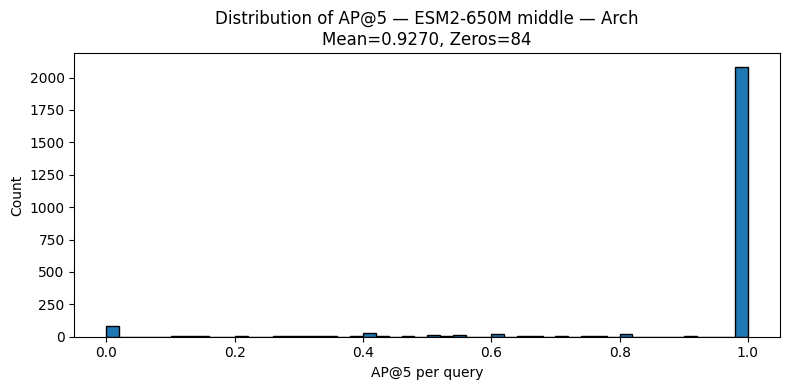

Queries with AP=1.0 (perfect): 2084
Queries with AP=0.0 (no hit):  84
Queries with AP>0 but <1:      175


In [ ]:
import matplotlib.pyplot as plt

key = ('650M', 'middle', 'arch')
retrieved_list = RETRIEVAL_RESULTS[key]
query_ids = TASK_CONFIG['arch']['query_ids']

per_query_ap = []
for qid, retrieved in zip(query_ids, retrieved_list):
    relevant = set(arch_qrels.get(qid, {}).keys())
    if relevant:
        per_query_ap.append(average_precision_at_k(retrieved, relevant))

plt.figure(figsize=(8, 4))
plt.hist(per_query_ap, bins=50, edgecolor='black')
plt.xlabel('AP@5 per query')
plt.ylabel('Count')
plt.title(f'Distribution of AP@5 — ESM2-650M middle — Arch\n'
          f'Mean={sum(per_query_ap)/len(per_query_ap):.4f}, '
          f'Zeros={sum(1 for x in per_query_ap if x==0)}')
plt.tight_layout()
plt.show()

print(f"Queries with AP=1.0 (perfect): {sum(1 for x in per_query_ap if x==1.0)}")
print(f"Queries with AP=0.0 (no hit):  {sum(1 for x in per_query_ap if x==0.0)}")
print(f"Queries with AP>0 but <1:      {sum(1 for x in per_query_ap if 0 < x < 1.0)}")

In [ ]:
# Inspect the actual fuzz_ratio distribution
task = ArchRetrieval()
meta = task.metadata
qrels_ds = meta.datasets[1].load()

import pandas as pd
df_qrels = pd.DataFrame(qrels_ds['train'])

print(df_qrels['fuzz_ratio'].describe())
print("\nValue counts (top 20):")
print(df_qrels['fuzz_ratio'].value_counts().head(20))
print(f"\nTotal pairs: {len(df_qrels)}")
print(f"Pairs with fuzz_ratio == 100: {(df_qrels['fuzz_ratio'] == 100).sum()}")
print(f"Pairs with fuzz_ratio >= 90:  {(df_qrels['fuzz_ratio'] >= 90).sum()}")
print(f"Pairs with fuzz_ratio >= 80:  {(df_qrels['fuzz_ratio'] >= 80).sum()}")

count    163612.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: fuzz_ratio, dtype: float64

Value counts (top 20):
fuzz_ratio
1    163612
Name: count, dtype: int64

Total pairs: 163612
Pairs with fuzz_ratio == 100: 0
Pairs with fuzz_ratio >= 90:  0
Pairs with fuzz_ratio >= 80:  0


In [ ]:
# Check the exact revision/commit being loaded
task = ArchRetrieval()
meta = task.metadata

print("Dataset 0 (sequences):")
print(f"  path:     {meta.datasets[0].path}")
print(f"  revision: {meta.datasets[0].revision}")

print("\nDataset 1 (qrels):")
print(f"  path:     {meta.datasets[1].path}")
print(f"  revision: {meta.datasets[1].revision}")

# Also check dgeb package version
import dgeb
print(f"\ndgeb version: {dgeb.__version__}")

Dataset 0 (sequences):
  path:     tattabio/arch_retrieval
  revision: a19124322604a21b26b1b3c13a1bd0b8a63c9f7b

Dataset 1 (qrels):
  path:     tattabio/arch_retrieval_qrels
  revision: 3f142f2f9a0995d56c6e77188c7251761450afcf


AttributeError: module 'dgeb' has no attribute '__version__'

In [ ]:
from datasets import load_dataset

# Load the qrels at a specific older revision to compare pair counts
# First check what revision your current dgeb version pins
print("Current qrels revision:", meta.datasets[1].revision)

# Try loading head of main to compare
ds_head = load_dataset(meta.datasets[1].path, split='train')
print(f"HEAD revision pair count: {len(ds_head)}")

Current qrels revision: 3f142f2f9a0995d56c6e77188c7251761450afcf
HEAD revision pair count: 163612


In [ ]:
# Does dgeb expose a direct evaluator you can call with precomputed embeddings?
import inspect
import dgeb

# Check what's available
print(dir(dgeb))

# Look at the task's evaluate method signature
task = ArchRetrieval()
print(inspect.getsource(task.evaluate))

['DGEB', 'Modality', 'TaskResult', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'dgeb', 'eval_utils', 'evaluators', 'get_all_model_names', 'get_all_task_names', 'get_all_tasks', 'get_model', 'get_output_folder', 'get_tasks_by_modality', 'get_tasks_by_name', 'modality', 'models', 'tasks']


AttributeError: 'ArchRetrieval' object has no attribute 'evaluate'

In [ ]:
# Step 1: Check what the qrels dataset actually looks like at that pinned revision
from datasets import load_dataset

# Load at the exact pinned revision
qrels_pinned = load_dataset(
    "tattabio/arch_retrieval_qrels",
    revision="3f142f2f9a0995d56c6e77188c7251761450afcf"
)
print("Splits:", list(qrels_pinned.keys()))
print("Features:", qrels_pinned[list(qrels_pinned.keys())[0]].features)
print("Total rows:", sum(len(qrels_pinned[s]) for s in qrels_pinned))
print("\nFirst 5 rows:")
for row in list(qrels_pinned[list(qrels_pinned.keys())[0]])[:5]:
    print(row)

Splits: ['train']
Features: {'query_id': Value('string'), 'corpus_id': Value('string'), 'fuzz_ratio': Value('int64')}
Total rows: 163612

First 5 rows:
{'query_id': 'A0A482D308', 'corpus_id': 'A0A2U3D0N8', 'fuzz_ratio': 1}
{'query_id': 'A0A482D308', 'corpus_id': 'P0DW62', 'fuzz_ratio': 1}
{'query_id': 'A3MTK6', 'corpus_id': 'A0Q5Y6', 'fuzz_ratio': 1}
{'query_id': 'A3MTK6', 'corpus_id': 'C9X1G6', 'fuzz_ratio': 1}
{'query_id': 'A3MTK6', 'corpus_id': 'G3ECR2', 'fuzz_ratio': 1}


In [ ]:
# Step 2: Load the HEAD version (no revision pin) and compare row counts
qrels_head = load_dataset("tattabio/arch_retrieval_qrels")
print("\nHEAD splits:", list(qrels_head.keys()))
print("HEAD total rows:", sum(len(qrels_head[s]) for s in qrels_head))
print("Pinned total rows:", sum(len(qrels_pinned[s]) for s in qrels_pinned))


HEAD splits: ['train']
HEAD total rows: 163612
Pinned total rows: 163612


In [ ]:
# Step 3: Check the sequences dataset for annotation columns
seq_pinned = load_dataset(
    "tattabio/arch_retrieval",
    revision="a19124322604a21b26b1b3c13a1bd0b8a63c9f7b"
)
print("Sequence dataset splits:", list(seq_pinned.keys()))
print("Columns:", seq_pinned[list(seq_pinned.keys())[0]].column_names)
print("\nFirst row sample:")
first_row = seq_pinned[list(seq_pinned.keys())[0]][0]
for k, v in first_row.items():
    val_preview = str(v)[:80] if v else "None"
    print(f"  {k}: {val_preview}")

Sequence dataset splits: ['train', 'test']
Columns: ['Entry', 'Sequence', 'Protein names']

First row sample:
  Entry: A9BHI9
  Sequence: MKDNILKRSFHHSKFENIKELVKLKEKQDVKISLAFPSLNEEKTIGKEIIIMKSELMEKYPLLDEIAVIDSGSEDETVSI
  Protein names: Glucosyl-3-phosphoglycerate synthase(EC 2.4.1.266)


In [ ]:
# Get the annotation columns from the sequences dataset
seq_ds = load_dataset(
    "tattabio/arch_retrieval",
    revision="a19124322604a21b26b1b3c13a1bd0b8a63c9f7b"
)
print("Splits:", list(seq_ds.keys()))
print("Columns:", seq_ds['train'].column_names)

# Show one full row so we can see all fields
print("\nFull first corpus row:")
for k, v in seq_ds['train'][0].items():
    print(f"  {k}: {str(v)[:120]}")

print("\nFull first query row:")
for k, v in seq_ds['test'][0].items():
    print(f"  {k}: {str(v)[:120]}")

Splits: ['train', 'test']
Columns: ['Entry', 'Sequence', 'Protein names']

Full first corpus row:
  Entry: A9BHI9
  Sequence: MKDNILKRSFHHSKFENIKELVKLKEKQDVKISLAFPSLNEEKTIGKEIIIMKSELMEKYPLLDEIAVIDSGSEDETVSIAKEYGAKVFYSSDILPEYGFYKGKGENLWKSLYALDGDII
  Protein names: Glucosyl-3-phosphoglycerate synthase(EC 2.4.1.266)

Full first query row:
  Entry: A0A482D308
  Sequence: MAKNTITKTLKLRIVRPYNSAEVEKIVADEKNNREKIALEKNKDKVKEACSKHLKVAAYCTTQVERNACLFCKARKLDDKFYQKLRGQFPDAVFWQEISEIFRQLQKQAAEIYNQSLIEL
  Protein names: CRISPR-associated endodeoxyribonuclease Cas12f1(EC 3.1.-.-)


In [ ]:
# Check what MAP formula DGEB uses internally
from dgeb.tasks import ArchRetrieval
import inspect

task = ArchRetrieval()
meta = task.metadata

# Find the evaluator class
print(type(meta))
print(dir(meta))

# Look at the task's evaluator
from dgeb import evaluators
print(dir(evaluators))

# Try to find the retrieval evaluator source
for name in dir(evaluators):
    obj = getattr(evaluators, name)
    if callable(obj) and 'retriev' in name.lower():
        print(f"\n{name}:")
        try:
            print(inspect.getsource(obj))
        except:
            print("  (source not available)")

<class 'dgeb.tasks.tasks.TaskMetadata'>
['__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pretty__', '__private_attributes__', '__pydantic_complete__', '__pydantic_computed_fields__', '__pydantic_core_schema__', '__pydantic_custom_init__', '__pydantic_decorators__', '__pydantic_extra__', '__pydantic_fields__', '__pydantic_fields_set__', '__pydantic_generic_metadata__', '__pydantic_init_subclass__', '__pydantic_on_complete__', '__pydantic_parent_namespace__', '__pydantic_post_init__', '__pydantic_private__', '__pydantic_root_model__', '__pydantic_serializer__', '__py

---
## Section 7: Twilight Zone Analysis

We bin **queries** by their maximum BLAST percent identity (`%ID`) to any corpus protein,
then compute MAP@5 separately per bin:

- **High similarity** : max %ID > 40%  
- **Medium similarity**: 20% ≤ max %ID ≤ 40%  
- **Twilight zone**   : max %ID < 20% (or no BLAST hit at all)

**FIX 3:** Queries with zero BLAST hits are assigned `pident = 0.0` so they are correctly
placed in the twilight zone bin rather than being silently dropped.

**Note on methodology:** We bin by *query-level* max %ID, which is standard in IR.
A query in the twilight bin is one where BLAST finds no corpus protein with >20% identity,
making it a genuinely hard case for alignment-based methods.

> **Prerequisite:** Upload `blast_pident.csv` from Method 1 (BLASTp notebook).  
> Expected columns: `query_id`, `corpus_id`, `pident`

In [ ]:
# Load BLAST percent identity data from Method 1
BLAST_PIDENT_PATH = os.path.join(CHECKPOINT_DIR, 'blast_pident.csv')

if os.path.exists(BLAST_PIDENT_PATH):
    df_blast = pd.read_csv(BLAST_PIDENT_PATH)
    print(f'Loaded BLAST pident data: {len(df_blast):,} rows')
    print(df_blast.head())
else:
    print('blast_pident.csv not found.')
    print('Upload the file from Method 1 to:', BLAST_PIDENT_PATH)
    print('Twilight zone analysis will be skipped.')
    df_blast = None

blast_pident.csv not found.
Upload the file from Method 1 to: /content/drive/MyDrive/esm2_checkpoints_690U/blast_pident.csv
Twilight zone analysis will be skipped.


In [ ]:
def bin_by_pident(pident: float) -> str:
    if pident >= 40:  return '>40% (High)'
    if pident >= 20:  return '20-40% (Medium)'
    return '<20% (Twilight)'


def twilight_zone_map(
    query_ids: list,
    retrieved_list: list,
    qrels: dict,
    df_blast_pident: pd.DataFrame,
    k: int = 5,
) -> dict:
    """
    Compute MAP@k per BLAST %ID bin.

    Each query is assigned to a bin based on its maximum BLAST %ID
    across all corpus hits. Queries with NO BLAST hit get pident=0.0
    and are placed in the twilight zone bin (FIX 3).
    """
    # Build lookup: query_id -> max pident across all BLAST hits
    max_pident_lookup = (
        df_blast_pident
        .groupby('query_id')['pident']
        .max()
        .to_dict()
    )

    bin_aps = {
        '>40% (High)':     [],
        '20-40% (Medium)': [],
        '<20% (Twilight)': [],
    }

    for qid, retrieved in zip(query_ids, retrieved_list):
        relevant = set(qrels.get(qid, {}).keys())
        if not relevant:
            continue
        # FIX 3: default to 0.0 for queries with no BLAST hit
        # → correctly placed in twilight zone, not silently dropped
        pident    = max_pident_lookup.get(str(qid), 0.0)
        bin_label = bin_by_pident(pident)
        ap        = average_precision_at_k(retrieved, relevant, k)
        bin_aps[bin_label].append(ap)

    return {
        bin_label: (
            float(np.mean(aps)) if aps else float('nan'),
            len(aps)
        )
        for bin_label, aps in bin_aps.items()
    }


if df_blast is not None:
    TZ_RESULTS = {}
    # Filter to arch task if 'task' column present
    df_blast_arch = (
        df_blast[df_blast['task'] == 'arch']
        if 'task' in df_blast.columns
        else df_blast
    )

    for size in ('35M', '150M', '650M'):
        best_row = df_best[
            (df_best['Method'] == f'ESM2-{size}') &
            (df_best['Task']   == 'Arch Retrieval')
        ]
        if best_row.empty:
            continue
        best_layer = best_row.iloc[0]['Layer']
        retrieved  = RETRIEVAL_RESULTS[(size, best_layer, 'arch')]

        tz = twilight_zone_map(
            TASK_CONFIG['arch']['query_ids'],
            retrieved,
            arch_qrels,
            df_blast_arch,
            k=5,
        )
        TZ_RESULTS[f'ESM2-{size}'] = tz
        print(f'ESM2-{size} (Arch Retrieval):')
        for bin_lbl, (score, n) in tz.items():
            score_str = f'{score:.4f}' if not np.isnan(score) else 'N/A (no queries)'
            print(f'  {bin_lbl:22s}: MAP@5={score_str}  n={n}')
else:
    TZ_RESULTS = {}
    print('Skipping twilight zone analysis (blast_pident.csv not found).')

Skipping twilight zone analysis (blast_pident.csv not found).


---
## Section 8: Visualization & Results Table

Three outputs:
1. **Table 1** — Main ESM2 results (all scales, best layer)
2. **Figure 1** — Scaling plot: MAP@5 vs. parameter count
3. **Figure 2** — Twilight zone grouped bar chart (Arch Retrieval)

In [ ]:
plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
})
COLORS = sns.color_palette('tab10')

In [ ]:
# Table 1 — ESM2 results with ESM2-3B reference row from DGEB paper
DGEB_3B_REF = [
    {'Method': 'ESM2-3B', 'Layer': 'best (DGEB reported)', 'Task': 'Arch Retrieval',
     'MAP@5': 0.313, 'nDCG@5': float('nan'), 'Recall@5': float('nan'), 'n_queries': 'ref'},
    {'Method': 'ESM2-3B', 'Layer': 'best (DGEB reported)', 'Task': 'Euk Retrieval',
     'MAP@5': 0.357, 'nDCG@5': float('nan'), 'Recall@5': float('nan'), 'n_queries': 'ref'},
]

df_table1 = pd.concat([
    df_best[display_cols],
    pd.DataFrame(DGEB_3B_REF)[display_cols],
], ignore_index=True)

print('\n=== TABLE 1 — ESM2 Results Summary (Method 3) ===')
print(df_table1.to_string(index=False, float_format='%.4f'))

In [ ]:
# Figure 1 — MAP@5 vs. parameter count (scaling plot)
# Fill in BLASTP_MAP and KMER_MAP from Method 1 & 2 results when available
PARAM_COUNTS = {'35M': 35e6, '150M': 150e6, '650M': 650e6, '3B': 3e9}
BLASTP_MAP   = {'arch': None, 'euk': None}   # fill from Method 1 notebook
KMER_MAP     = {'arch': None, 'euk': None}   # fill from Method 2 notebook

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, (task, task_label) in zip(axes, [('arch', 'Arch Retrieval'), ('euk', 'Euk Retrieval')]):
    esm2_rows = df_best[df_best['Task'] == task_label].copy()
    esm2_rows['params'] = (
        esm2_rows['Method']
        .str.extract(r'(\d+M|\d+B)')[0]
        .map(PARAM_COUNTS)
    )
    esm2_rows = esm2_rows.dropna(subset=['params']).sort_values('params')

    ref_map     = 0.313 if task == 'arch' else 0.357
    esm2_params = list(esm2_rows['params']) + [3e9]
    esm2_maps   = list(esm2_rows['MAP@5'])  + [ref_map]

    ax.plot(esm2_params, esm2_maps, 'o-', color=COLORS[0], label='ESM2 (ours)', linewidth=2)
    ax.scatter([3e9], [ref_map], marker='*', s=200, color=COLORS[0],
               label='ESM2-3B (DGEB paper)', zorder=5)

    if BLASTP_MAP[task] is not None:
        ax.axhline(BLASTP_MAP[task], linestyle='--', color=COLORS[1], label='BLASTp')
    if KMER_MAP[task] is not None:
        ax.axhline(KMER_MAP[task],  linestyle=':',  color=COLORS[2], label='Best k-mer')

    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{int(x/1e6)}M' if x < 1e9 else f'{x/1e9:.0f}B'
    ))
    ax.set_xlabel('ESM2 Parameters', fontsize=11)
    ax.set_ylabel('MAP@5', fontsize=11)
    ax.set_title(task_label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Figure 1 — ESM2 Scaling: MAP@5 vs. Model Size', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(CHECKPOINT_DIR, 'fig1_scaling_plot.png'), bbox_inches='tight')
plt.show()
print('Saved: fig1_scaling_plot.png')

In [ ]:
# Figure 2 — Twilight zone grouped bar chart (Arch Retrieval)
if TZ_RESULTS:
    BIN_ORDER    = ['<20% (Twilight)', '20-40% (Medium)', '>40% (High)']
    method_names = list(TZ_RESULTS.keys())
    x     = np.arange(len(BIN_ORDER))
    width = 0.22

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (method, tz_data) in enumerate(TZ_RESULTS.items()):
        scores = [tz_data[b][0] for b in BIN_ORDER]
        ns     = [tz_data[b][1] for b in BIN_ORDER]
        offset = (i - len(method_names) / 2 + 0.5) * width
        bars   = ax.bar(x + offset, scores, width, label=method, color=COLORS[i], alpha=0.85)
        for bar, n, score in zip(bars, ns, scores):
            if bar.get_height() > 0 and not np.isnan(score):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f'n={n}', ha='center', va='bottom', fontsize=7
                )

    ax.set_xticks(x)
    ax.set_xticklabels(BIN_ORDER, fontsize=10)
    ax.set_ylabel('MAP@5', fontsize=11)
    ax.set_title(
        'Figure 2 — Twilight Zone Analysis (Arch Retrieval)\n'
        'MAP@5 by Maximum BLAST % Identity of Query',
        fontsize=12, fontweight='bold'
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(os.path.join(CHECKPOINT_DIR, 'fig2_twilight_zone.png'), bbox_inches='tight')
    plt.show()
    print('Saved: fig2_twilight_zone.png')
else:
    print('Twilight zone figure skipped (no BLAST pident data).')
    print('Re-run Section 7 after uploading blast_pident.csv from Method 1.')

In [ ]:
# Supplementary — Middle vs Last Layer comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, task_label in zip(axes, ('Arch Retrieval', 'Euk Retrieval')):
    task_df = df_results[df_results['Task'] == task_label].copy()
    sizes   = ['35M', '150M', '650M']
    x       = np.arange(len(sizes))
    width   = 0.35

    for j, layer in enumerate(('middle', 'last')):
        layer_df = task_df[task_df['Layer'] == layer].set_index('Method')
        scores   = [
            layer_df.loc[f'ESM2-{s}', 'MAP@5']
            if f'ESM2-{s}' in layer_df.index else 0.0
            for s in sizes
        ]
        offset = (j - 0.5) * width
        ax.bar(x + offset, scores, width,
               label=f'{layer.capitalize()} layer', color=COLORS[j + 3], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([f'ESM2-{s}' for s in sizes])
    ax.set_ylabel('MAP@5')
    ax.set_title(f'{task_label}\nMiddle vs. Last Encoder Layer', fontweight='bold')
    ax.legend()

fig.suptitle('Supplementary — Layer Selection Effect on MAP@5', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(CHECKPOINT_DIR, 'supp_layer_comparison.png'), bbox_inches='tight')
plt.show()

In [ ]:
# Final summary for paper Table 1
print('=' * 70)
print('FINAL RESULTS — ESM2 Embeddings (Method 3)')
print('=' * 70)
for task_label in ('Arch Retrieval', 'Euk Retrieval'):
    print(f'\n{task_label}:')
    t = df_best[
        df_best['Task'] == task_label
    ][['Method', 'Layer', 'MAP@5', 'nDCG@5', 'Recall@5']]
    print(t.to_string(index=False, float_format='%.4f'))
    ref = 0.313 if 'Arch' in task_label else 0.357
    print(f'  ESM2-3B (DGEB paper ref): MAP@5 = {ref}')

print('\nAll outputs saved to:', CHECKPOINT_DIR)

In [1]:
# ── Save per-query AP scores for twilight zone analysis ──────────────────────
import pandas as pd
import pytrec_eval

def per_query_ap(query_ids, retrieved_list, qrels, k=5):
    results = {
        qid: {cid: 1.0/(r+1) for r, cid in enumerate(ret)}
        for qid, ret in zip(query_ids, retrieved_list)
        if qid in qrels
    }
    ev = pytrec_eval.RelevanceEvaluator(qrels, {f'map_cut.{k}'})
    scores = ev.evaluate(results)
    return {qid: scores[qid][f'map_cut_{k}'] for qid in scores}


# Arch — ESM2-650M middle layer (your best model)
arch_q_emb = load_checkpoint('650M', 'arch', 'queries')
arch_c_emb = load_checkpoint('650M', 'arch', 'corpus')
arch_retrieved = cosine_retrieve(
    arch_q_emb['middle'], arch_c_emb['middle'], arch_c_emb['ids'], top_k=5
)
arch_ap = per_query_ap(arch_q_emb['ids'], arch_retrieved, arch_qrels)

df_arch_ap = pd.DataFrame([
    {'query_id': qid, 'esm2_ap': ap}
    for qid, ap in arch_ap.items()
])
arch_ap_path = os.path.join(CHECKPOINT_DIR, 'esm2_arch_per_query_ap.csv')
df_arch_ap.to_csv(arch_ap_path, index=False)
print(f'Arch per-query AP saved: {arch_ap_path}  ({len(df_arch_ap)} rows)')


# Euk — ESM2-650M middle layer
euk_q_emb = load_checkpoint('650M', 'euk', 'queries')
euk_c_emb = load_checkpoint('650M', 'euk', 'corpus')
euk_retrieved = cosine_retrieve(
    euk_q_emb['middle'], euk_c_emb['middle'], euk_c_emb['ids'], top_k=5
)
euk_ap = per_query_ap(euk_q_emb['ids'], euk_retrieved, euk_qrels)

df_euk_ap = pd.DataFrame([
    {'query_id': qid, 'esm2_ap': ap}
    for qid, ap in euk_ap.items()
])
euk_ap_path = os.path.join(CHECKPOINT_DIR, 'esm2_euk_per_query_ap.csv')
df_euk_ap.to_csv(euk_ap_path, index=False)
print(f'Euk per-query AP saved:  {euk_ap_path}  ({len(df_euk_ap)} rows)')

ModuleNotFoundError: No module named 'pytrec_eval'